In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python EDA started successfully!")

Python EDA started successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()


Saving ecommerce_sales_cleaned.xlsx to ecommerce_sales_cleaned (1).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("ecommerce_sales_cleaned.xlsx", sheet_name="Sheet1")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (8000, 13)


In [ ]:
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Mode
0,ORD100000,2026-01-16,CUST1160,Customer_160,Coffee Maker,Home & Kitchen,East,2,17623.29,0.15,29959.59,4397.29,Debit Card
1,ORD100001,2026-04-05,CUST1870,Customer_870,Yoga Mat,Sports,Central,1,5992.14,0.10,5392.93,619.92,UPI
2,ORD100002,2025-01-07,CUST1762,Customer_762,Desk,Office,North,4,15295.43,0.10,55063.55,9130.98,UPI
3,ORD100003,2025-01-29,CUST1224,Customer_224,Smartphone,Electronics,North,2,47561.04,0.05,90365.98,10421.99,UPI
4,ORD100004,2025-02-02,CUST1180,Customer_180,Vacuum Cleaner,Home & Kitchen,South,4,3615.74,0.00,14462.96,2280.64,UPI


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       8000 non-null   object        
 1   Order_Date     8000 non-null   datetime64[ns]
 2   Customer_ID    8000 non-null   object        
 3   Customer_Name  8000 non-null   object        
 4   Product        8000 non-null   object        
 5   Category       8000 non-null   object        
 6   Region         8000 non-null   object        
 7   Quantity       8000 non-null   int64         
 8   Unit_Price     8000 non-null   float64       
 9   Discount       8000 non-null   float64       
 10  Sales          8000 non-null   float64       
 11  Profit         8000 non-null   float64       
 12  Payment_Mode   8000 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(7)
memory usage: 812.6+ KB


In [ ]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Product          0
Category         0
Region           0
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Profit           0
Payment_Mode     0
dtype: int64

Number of duplicate rows:
0


In [ ]:
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
Order_ID                 object
Order_Date       datetime64[ns]
Customer_ID              object
Customer_Name            object
Product                  object
Category                 object
Region                   object
Quantity                  int64
Unit_Price              float64
Discount                float64
Sales                   float64
Profit                  float64
Payment_Mode             object
dtype: object


In [ ]:
# Statistical summary of numerical columns

df.describe()

,Order_Date,Quantity,Unit_Price,Discount,Sales,Profit
count,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,2025-10-02 02:15:10.800000,1.888875,15665.652274,0.094656,26306.979733,3195.492686
min,2025-01-01 00:00:00,1.000000,253.770000,0.000000,198.910000,15.580000
25%,2025-05-18 00:00:00,1.000000,4229.207500,0.050000,5626.282500,896.422500
50%,2025-09-30 12:00:00,2.000000,8537.035000,0.100000,12558.625000,1860.610000
75%,2026-02-18 00:00:00,2.000000,16756.577500,0.150000,28417.380000,3820.937500
max,2026-06-30 00:00:00,5.000000,89997.530000,0.250000,387626.620000,51817.510000
std,NaN,1.068723,19536.329956,0.064443,39743.596741,4102.826572


In [ ]:
# Summary of Sales and Profit

df[["Sales", "Profit"]].describe()

,Sales,Profit
count,8000.000000,8000.000000
mean,26306.979733,3195.492686
std,39743.596741,4102.826572
min,198.910000,15.580000
25%,5626.282500,896.422500
50%,12558.625000,1860.610000
75%,28417.380000,3820.937500
max,387626.620000,51817.510000


In [ ]:
# Average Sales and Profit

print("Average Sales:", df["Sales"].mean())
print("Average Profit:", df["Profit"].mean())

Average Sales: 26306.979732500004
Average Profit: 3195.4926862499997


In [ ]:
category_analysis = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Sales=("Sales", "mean")
).sort_values("Total_Sales", ascending=False)

category_analysis

,Total_Sales,Total_Profit,Average_Sales
Category,,,
Electronics,1.208751e+08,10764325.95,74845.287523
Office,3.653677e+07,5866521.74,22010.104343
Home & Kitchen,2.618020e+07,3618019.76,16465.532811
Sports,1.671388e+07,3002924.64,10659.361779
Beauty,1.014985e+07,2312149.40,6477.248794


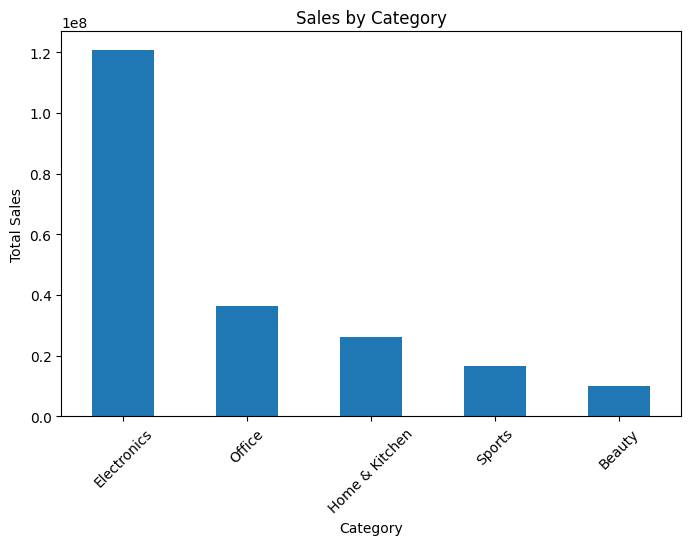

In [ ]:
category_analysis["Total_Sales"].plot(
    kind="bar",
    figsize=(8,5),
    title="Sales by Category"
)

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [ ]:
category_analysis["Profit_Margin"] = (
    category_analysis["Total_Profit"] /
    category_analysis["Total_Sales"]
) * 100

category_analysis.sort_values(
    "Profit_Margin",
    ascending=False
)

,Total_Sales,Total_Profit,Average_Sales,Profit_Margin
Category,,,,
Beauty,1.014985e+07,2312149.40,6477.248794,22.780136
Sports,1.671388e+07,3002924.64,10659.361779,17.966653
Office,3.653677e+07,5866521.74,22010.104343,16.056486
Home & Kitchen,2.618020e+07,3618019.76,16465.532811,13.819681
Electronics,1.208751e+08,10764325.95,74845.287523,8.905327


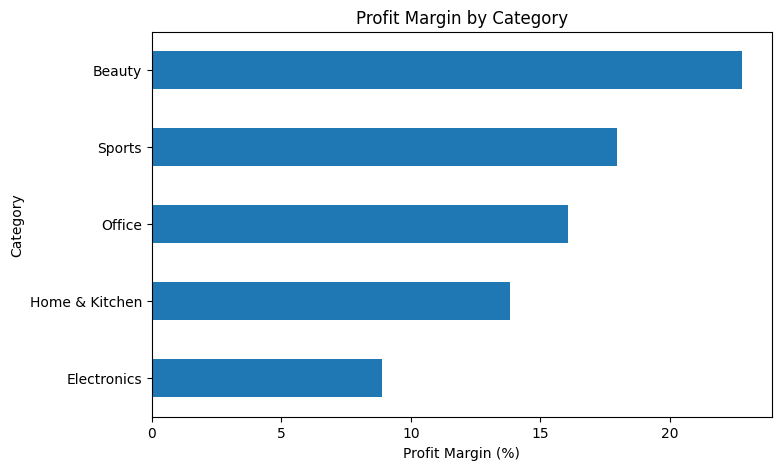

In [ ]:
category_analysis["Profit_Margin"].sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Profit Margin by Category"
)

plt.xlabel("Profit Margin (%)")
plt.ylabel("Category")
plt.show()

In [ ]:
product_analysis = df.groupby("Product").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Quantity_Sold=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

product_analysis

,Total_Sales,Total_Profit,Quantity_Sold
Product,,,
Smartwatch,20631488.73,1916699.45,512
Monitor,20526096.61,1788396.18,491
Headphones,20468318.78,1762672.85,538
Tablet,20419941.10,1828085.88,505
Smartphone,19827411.73,1875036.70,496
Laptop,19001882.40,1593434.89,459
Office Chair,6257107.02,1024174.32,529
Webcam,6250379.11,986741.61,528
Printer,6215648.21,985926.00,546


In [ ]:
top10_products = product_analysis.head(10)

top10_products

,Total_Sales,Total_Profit,Quantity_Sold
Product,,,
Smartwatch,20631488.73,1916699.45,512
Monitor,20526096.61,1788396.18,491
Headphones,20468318.78,1762672.85,538
Tablet,20419941.10,1828085.88,505
Smartphone,19827411.73,1875036.70,496
Laptop,19001882.40,1593434.89,459
Office Chair,6257107.02,1024174.32,529
Webcam,6250379.11,986741.61,528
Printer,6215648.21,985926.00,546


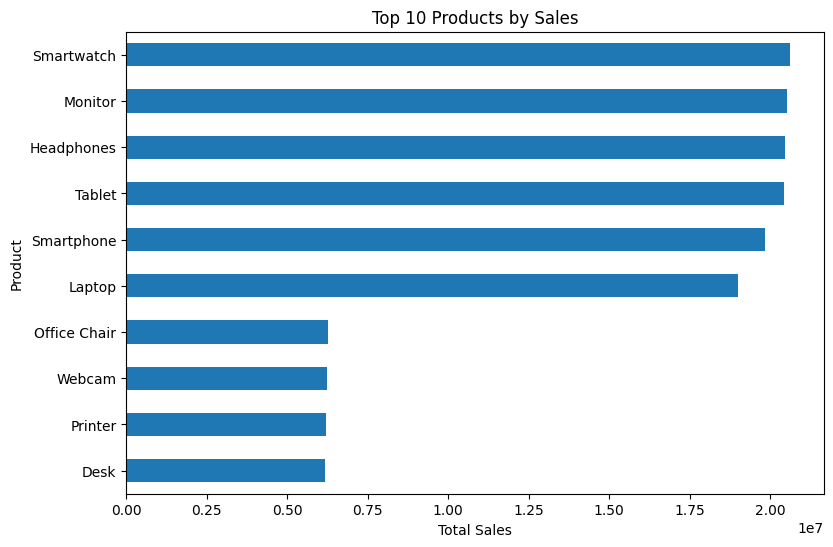

In [ ]:
top10_products["Total_Sales"].sort_values().plot(
    kind="barh",
    figsize=(9,6),
    title="Top 10 Products by Sales"
)

plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.show()

In [ ]:
customer_analysis = df.groupby("Customer_ID").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique")
).sort_values("Total_Sales", ascending=False)

customer_analysis.head(10)

,Total_Sales,Total_Profit,Orders
Customer_ID,,,
CUST1999,777028.35,79343.08,8
CUST2068,701719.94,67569.93,6
CUST1095,661563.87,55330.20,11
CUST1927,657598.25,72675.50,5
CUST1359,651416.71,54433.04,7
CUST1025,645667.47,73042.31,7
CUST1993,622727.30,47680.69,8
CUST1233,614594.57,63225.59,7
CUST1762,580931.09,62520.20,14


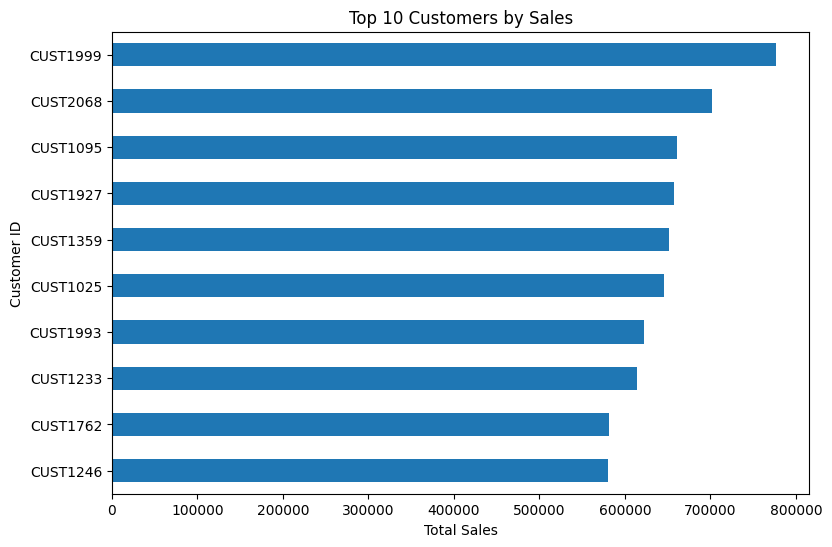

In [ ]:
top10_customers = customer_analysis.head(10)

top10_customers["Total_Sales"].sort_values().plot(
    kind="barh",
    figsize=(9,6),
    title="Top 10 Customers by Sales"
)

plt.xlabel("Total Sales")
plt.ylabel("Customer ID")
plt.show()

In [ ]:
region_analysis = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique")
).sort_values("Total_Sales", ascending=False)

region_analysis

,Total_Sales,Total_Profit,Orders
Region,,,
South,65877682.15,8028512.71,2528
West,42345477.95,5083896.60,1582
North,41732238.73,5029511.08,1641
East,33270300.23,4065534.50,1246
Central,27230138.80,3356486.60,1003


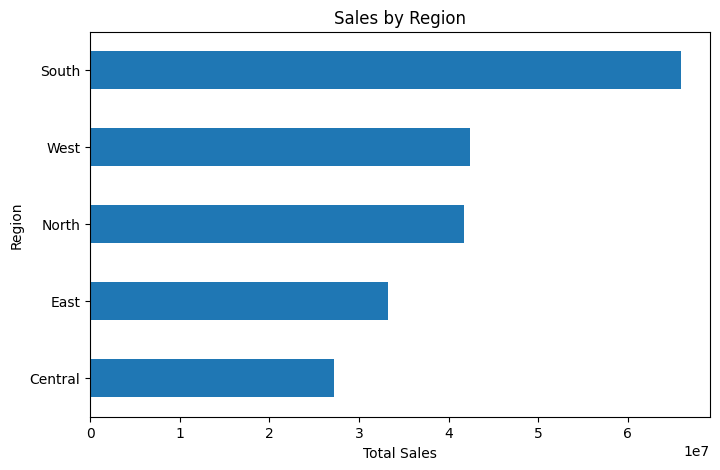

In [ ]:
region_analysis["Total_Sales"].sort_values().plot(
    kind="barh",
    figsize=(8,5),
    title="Sales by Region"
)

plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.show()

In [ ]:
region_analysis["Profit_Margin"] = (
    region_analysis["Total_Profit"] /
    region_analysis["Total_Sales"]
) * 100

region_analysis.sort_values("Profit_Margin", ascending=False)

,Total_Sales,Total_Profit,Orders,Profit_Margin
Region,,,,
Central,27230138.80,3356486.60,1003,12.326366
East,33270300.23,4065534.50,1246,12.219711
South,65877682.15,8028512.71,2528,12.186999
North,41732238.73,5029511.08,1641,12.051860
West,42345477.95,5083896.60,1582,12.005760


In [ ]:
discount_analysis = df.groupby("Discount").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

discount_analysis["Profit_Margin"] = (
    discount_analysis["Total_Profit"] /
    discount_analysis["Total_Sales"]
) * 100

discount_analysis

,Total_Sales,Total_Profit,Profit_Margin
Discount,,,
0.00,33836077.63,5645283.97,16.684215
0.05,55072719.84,7705059.74,13.990701
0.10,62714492.27,7269746.20,11.591812
0.15,37076421.30,3423408.00,9.233383
0.20,16650631.60,1201076.79,7.213401
0.25,5105495.22,319366.79,6.255354


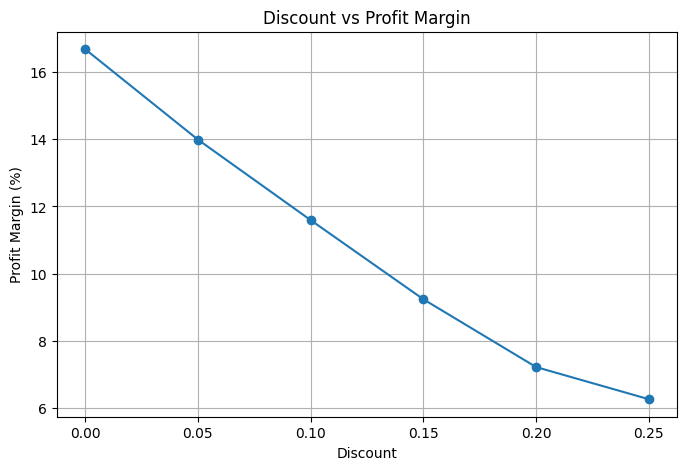

In [ ]:
discount_analysis["Profit_Margin"].plot(
    kind="line",
    marker="o",
    figsize=(8,5),
    title="Discount vs Profit Margin"
)

plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.grid(True)
plt.show()

In [ ]:
# Make sure Order_Date is a date
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# Monthly sales and profit
monthly_analysis = df.groupby(
    df["Order_Date"].dt.to_period("M")
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

monthly_analysis

,Total_Sales,Total_Profit
Order_Date,,
2025-01,12989029.64,1582996.50
2025-02,10253440.54,1176726.23
2025-03,11608277.88,1389173.31
2025-04,11286864.84,1310304.77
2025-05,11124611.37,1385733.03
2025-06,12308066.19,1357663.06
2025-07,13546148.59,1644644.94
2025-08,12246743.53,1490620.36
2025-09,10144641.29,1301524.62


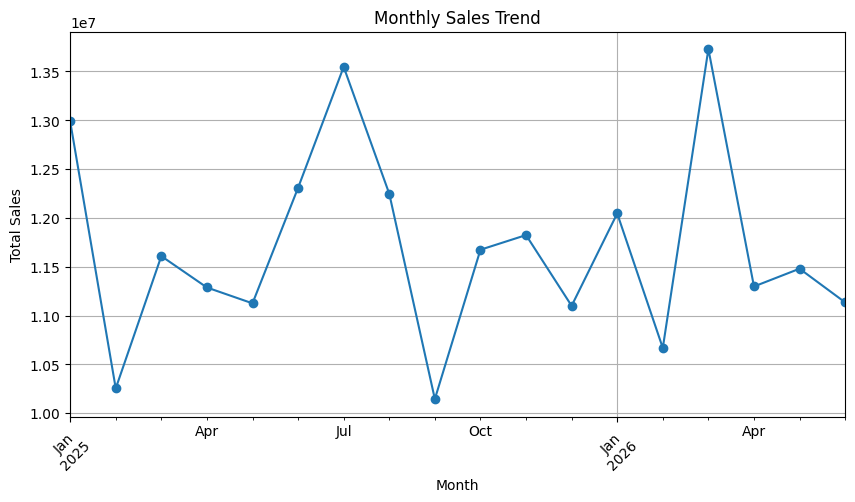

In [ ]:
monthly_analysis["Total_Sales"].plot(
    kind="line",
    figsize=(10,5),
    marker="o",
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

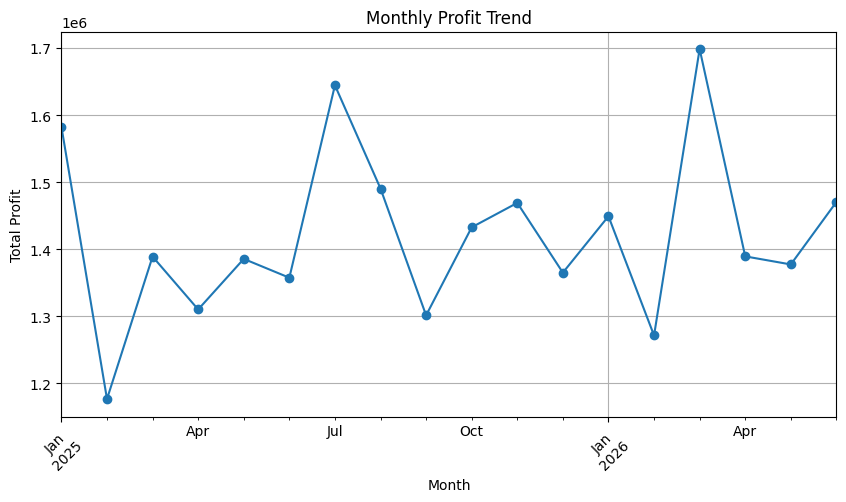

In [ ]:
monthly_analysis["Total_Profit"].plot(
    kind="line",
    figsize=(10,5),
    marker="o",
    title="Monthly Profit Trend"
)

plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
# Select important numerical columns
numeric_cols = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Sales",
    "Profit"
]

correlation = df[numeric_cols].corr()

correlation

,Quantity,Unit_Price,Discount,Sales,Profit
Quantity,1.000000,-0.023912,-0.006173,0.352151,0.413881
Unit_Price,-0.023912,1.000000,0.007102,0.801550,0.641803
Discount,-0.006173,0.007102,1.000000,-0.035530,-0.224117
Sales,0.352151,0.801550,-0.035530,1.000000,0.868156
Profit,0.413881,0.641803,-0.224117,0.868156,1.000000


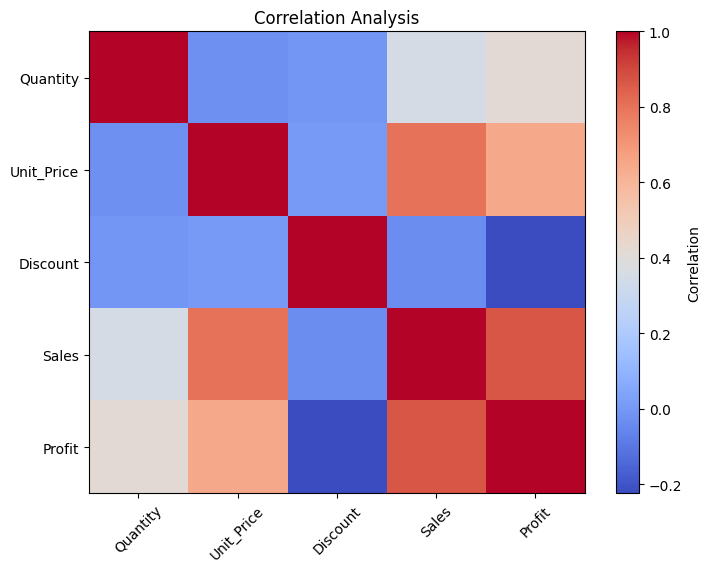

In [ ]:
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar(label="Correlation")
plt.title("Correlation Analysis")

plt.show()

In [ ]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

sales_outliers = df[
    (df["Sales"] < lower_limit) |
    (df["Sales"] > upper_limit)
]

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of Sales outliers:", len(sales_outliers))

Lower limit: -28560.36374999999
Upper limit: 62604.02624999999
Number of Sales outliers: 839


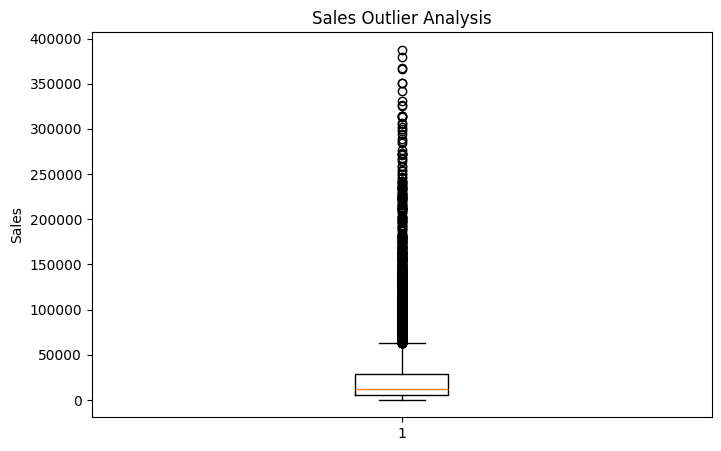

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Sales"])

plt.title("Sales Outlier Analysis")
plt.ylabel("Sales")

plt.show()

In [ ]:
Q1_profit = df["Profit"].quantile(0.25)
Q3_profit = df["Profit"].quantile(0.75)

IQR_profit = Q3_profit - Q1_profit

lower_profit = Q1_profit - 1.5 * IQR_profit
upper_profit = Q3_profit + 1.5 * IQR_profit

profit_outliers = df[
    (df["Profit"] < lower_profit) |
    (df["Profit"] > upper_profit)
]

print("Number of Profit outliers:", len(profit_outliers))

Number of Profit outliers: 628


In [ ]:
eda_summary = {
    "Total Rows": len(df),
    "Total Columns": len(df.columns),
    "Total Sales": df["Sales"].sum(),
    "Total Profit": df["Profit"].sum(),
    "Average Sales": df["Sales"].mean(),
    "Average Profit": df["Profit"].mean(),
    "Unique Customers": df["Customer_ID"].nunique(),
    "Unique Products": df["Product"].nunique(),
    "Unique Categories": df["Category"].nunique(),
    "Unique Regions": df["Region"].nunique()
}

eda_summary

{'Total Rows': 8000,
 'Total Columns': 13,
 'Total Sales': np.float64(210455837.86),
 'Total Profit': np.float64(25563941.49),
 'Average Sales': np.float64(26306.979732500004),
 'Average Profit': np.float64(3195.4926862499997),
 'Unique Customers': 1199,
 'Unique Products': 30,
 'Unique Categories': 5,
 'Unique Regions': 5}

In [ ]:
print("===== EDA SUMMARY =====")

for key, value in eda_summary.items():
    print(f"{key}: {value:,.2f}" if isinstance(value, (int, float)) else f"{key}: {value}")

===== EDA SUMMARY =====
Total Rows: 8,000.00
Total Columns: 13.00
Total Sales: 210,455,837.86
Total Profit: 25,563,941.49
Average Sales: 26,306.98
Average Profit: 3,195.49
Unique Customers: 1,199.00
Unique Products: 30.00
Unique Categories: 5.00
Unique Regions: 5.00
